# 4. Feature Engineering & Model Inputs

Build the model-ready matrix with `src.features`, inspect correlations and class balance, and confirm the inputs that Phase 5 modeling uses.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

# Anchor to the repo root regardless of where the kernel starts.
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print("Repo root:", ROOT)


Repo root: V:\E-commerce Order Fulfillment Operations Analysis


In [2]:
df = pd.read_csv(ROOT / "data" / "processed" / "orders_clean.csv", parse_dates=["Order Date & Time"])
df["is_delayed"] = df["is_delayed"].astype(bool)
print("Rows:", len(df), "| Cols:", df.shape[1])
df.head()

Rows: 100000 | Cols: 16


,Order ID,Customer ID,Platform,Order Date & Time,Promised Delivery (Minutes),Actual Delivery (Minutes),Product Category,Order Value (INR),Items Count,Customer Feedback,Service Rating,Delivery Delay,Refund Requested,is_delayed,order_weekday,order_hour
0,ORD000001,CUST0002,Swiggy Instamart,2024-11-01 00:00:51,35,50,Personal Care,1490,3,"Horrible experience, never ordering again.",1,Yes,Yes,True,4,0
1,ORD000002,CUST0007,Blinkit,2024-11-01 00:05:10,29,24,Personal Care,966,2,Packaging could be better.,3,No,No,False,4,0
2,ORD000003,CUST0002,Swiggy Instamart,2024-11-01 00:08:29,23,16,Grocery,340,5,Product quality was average.,4,No,No,False,4,0
3,ORD000004,CUST0001,Swiggy Instamart,2024-11-01 00:15:19,31,44,Snacks,169,12,Items missing from order.,3,Yes,No,True,4,0
4,ORD000005,CUST0001,Swiggy Instamart,2024-11-01 00:17:23,32,27,Personal Care,172,2,Cold items arrived melted.,2,No,No,False,4,0


## Build the feature matrix from source

In [3]:
import sys
sys.path.insert(0, str(ROOT))
from src.features import build_features

feat = build_features(df)
print('Feature matrix:', feat.shape)
feat.head()

Feature matrix: (100000, 21)


,order_id,minutes_late,order_value,items_count,promised_minutes,weekday,hour,service_rating,is_delayed,value_bucket,delay_and_high_value,platform_Blinkit,platform_JioMart,platform_Swiggy Instamart,category_Beverages,category_Dairy,category_Fruits & Vegetables,category_Grocery,category_Personal Care,category_Snacks,refund_requested
0,ORD000001,15,1490,3,35,4,0,1,1,premium,1,0,0,1,0,0,0,0,1,0,1
1,ORD000002,0,966,2,29,4,0,3,0,high,0,1,0,0,0,0,0,0,1,0,0
2,ORD000003,0,340,5,23,4,0,4,0,mid,0,0,0,1,0,0,0,1,0,0,0
3,ORD000004,13,169,12,31,4,0,3,1,low,0,0,0,1,0,0,0,0,0,1,0
4,ORD000005,0,172,2,32,4,0,2,0,low,0,0,0,1,0,0,0,0,1,0,0


## Target class balance

Refunded : 18751 (18.8%)
Not refunded: 81249


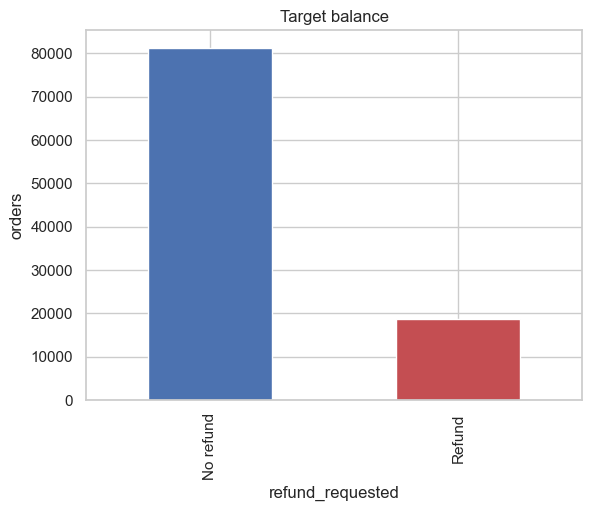

In [4]:
print('Refunded :', int(feat['refund_requested'].sum()), f"({100 * feat['refund_requested'].mean():.1f}%)")
print('Not refunded:', int((feat['refund_requested'] == 0).sum()))
feat['refund_requested'].value_counts().rename(index={0: 'No refund', 1: 'Refund'}).plot(kind='bar', color=['#4C72B0', '#C44E52'], title='Target balance')
plt.ylabel('orders'); plt.show()

## Correlation with the refund target

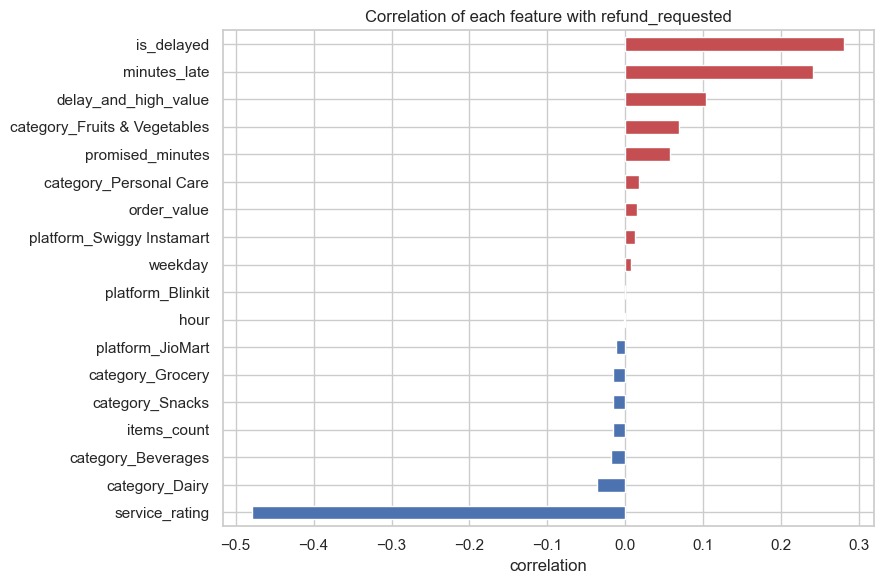

In [5]:
numeric = feat.drop(columns=['order_id']).select_dtypes(include='number')
corr = numeric.corr()['refund_requested'].drop('refund_requested').sort_values()
corr.plot(kind='barh', figsize=(9, 6), color=['#C44E52' if v > 0 else '#4C72B0' for v in corr.values], title='Correlation of each feature with refund_requested')
plt.xlabel('correlation'); plt.tight_layout(); plt.show()

## Full correlation heatmap

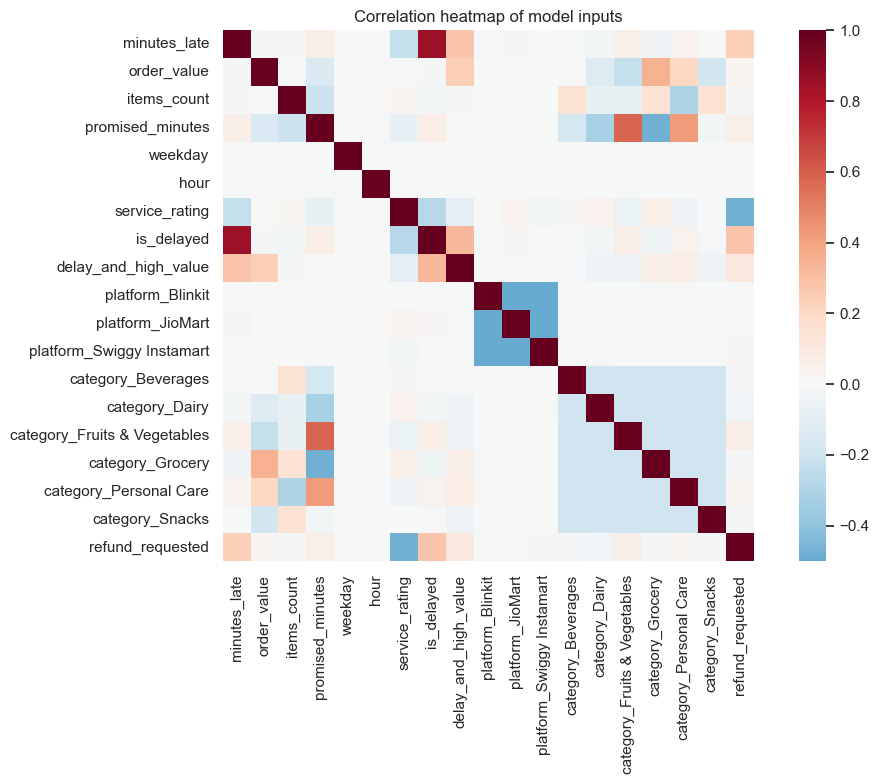

In [6]:
plt.figure(figsize=(11, 8))
sns.heatmap(numeric.corr(), cmap='RdBu_r', center=0, annot=False, square=True)
plt.title('Correlation heatmap of model inputs')
plt.tight_layout(); plt.show()

## Engineered feature distributions

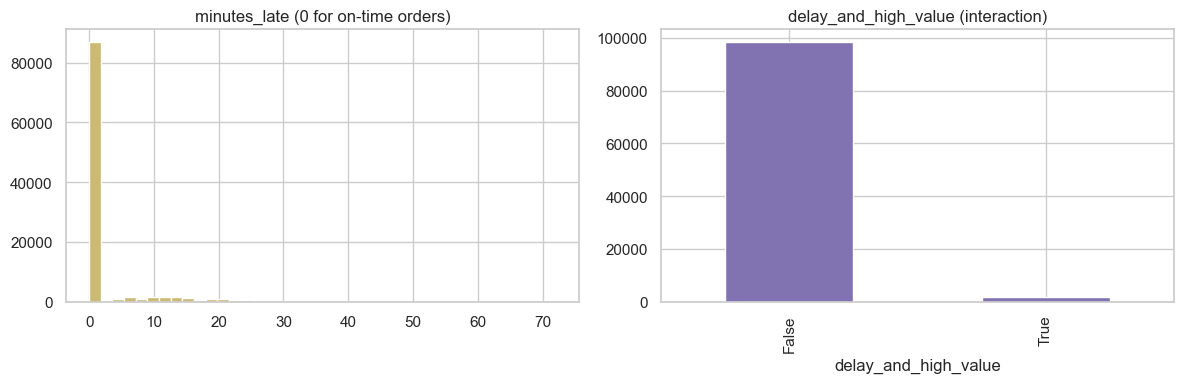

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
feat['minutes_late'].hist(bins=40, ax=axes[0], color='#CCB974')
axes[0].set_title('minutes_late (0 for on-time orders)')
feat['delay_and_high_value'].value_counts().reindex([0, 1]).plot(kind='bar', ax=axes[1], color='#8172B2', title='delay_and_high_value (interaction)')
axes[1].set_xticklabels(['False', 'True'])
plt.tight_layout(); plt.show()

## Key takeaways
- The feature matrix has **100,000 rows x 19 columns** - fully numeric and model-ready.
- Strongest signals for refund: **service rating**, **delay status** (`minutes_late` / `delay_and_high_value`), then **order value**; platform/category contribute modestly.
- Target is imbalanced (18.7% refunds) - the model will handle this with class weighting (Phase 5).
- `minutes_late` is right-skewed with a large zero mass (on-time orders), which is why the binned and interaction features exist.
- **This notebook reproduces `src/features.py` and prepares `data/processed/features.csv` for modeling.**